# all

In [13]:
import pandas as pd
import os
import random
import chardet
import requests
import json
import numpy as np
from urllib3.util.retry import Retry
import openai
from requests.adapters import HTTPAdapter
import os
import pickle
import matplotlib.pyplot as plt
# from utils.read_group_danmu import read_group_danmu

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import os

font_path = '/mnt/dataset0/lzs/.fonts/arial.ttf'  # 1) 路径要确认存在
assert os.path.exists(font_path), f"字体文件不存在: {font_path}"

# 2) 注册字体到 Matplotlib 的 fontManager（关键！）
fm.fontManager.addfont(font_path)

# 3) 读取这份 ttf 的“内部字体名”（可能是 Arial / ArialMT 等）
font_name = fm.FontProperties(fname=font_path).get_name()
print("Internal font name =", font_name)

# 4) 彻底避免去找 'Arial' 这个字符串
mpl.rcParams['font.family'] = [font_name]       # 用内部名
mpl.rcParams['font.sans-serif'] = [font_name]   # 避免回退到其他 sans-serif
mpl.rcParams['axes.unicode_minus'] = False

# （可选）如果你曾经设置过 'Arial'，先清理干净：
# mpl.rcParams['font.family'] = 'sans-serif'
# mpl.rcParams['font.sans-serif'] = [font_name]

# # 5) 画个图测试（坐标轴/标题/文字都应使用该字体，不再报错）
# plt.figure()
# plt.title('Title uses the registered font')
# plt.xlabel('X 轴')
# plt.ylabel('Y 轴')
# plt.text(0.5, 0.5, 'Hello Arial (from file)', ha='center', va='center')
# plt.show()


Internal font name = Arial


In [15]:
r_list=np.zeros(6)
r2_list=np.zeros(6)
p_list=np.zeros(6)
perm_rho_list = [[] for _ in range(6)]

## trajectory

In [16]:
with open(r'/mnt/dataset1/xinke/Danmu/DyEmo-film/Emotion_scores/scores_allMovies_resample.pkl', 'rb') as f:
    scores_dict = pickle.load(f)
# del scores_dict['BV1zW411d7Rb']
with open(r'/mnt/dataset1/xinke/Danmu/DyEmo-film/Emotion_scores/times_allMovies_resample.pkl', 'rb') as f:
    time_dict= pickle.load(f)
# del time_dict['BV1zW411d7Rb']

print(len(scores_dict.keys()))
print(len(time_dict.keys()))

102
102


In [17]:
scores_all = np.zeros((0,6))
n_samples = []

scores_key = list(scores_dict.keys())
count = 0
for key in scores_key:
    # print(scores_dict[key].shape)
    scores_all = np.concatenate((scores_all, scores_dict[key]), 0)
    n_samples.append(scores_dict[key].shape[0])
    count += 1
print(scores_all.shape)
n_samples_cum = np.concatenate((np.array([0]), np.cumsum(n_samples)))
print(n_samples_cum[-5:])

(356168, 6)
[343322 346152 349604 352228 356168]


In [18]:
import re
df = pd.read_csv('/mnt/dataset1/xinke/Danmu/DyEmo-film/movie_info_final3.csv')
bvid_list = df.loc[:18,'BVID'].tolist()+scores_key[18:-1]

In [19]:
from scipy.interpolate import interp1d

def resample_curve(curve, target_len=1000):
    """
    curve: np.ndarray, shape = (T, 6)
    return: np.ndarray, shape = (target_len, 6)
    """
    curve = np.asarray(curve)

    if curve.ndim != 2:
        raise ValueError(f"curve should be 2D, got shape {curve.shape}")

    T, D = curve.shape
    if D != 6:
        raise ValueError(f"Expected 6 dimensions, got {D}")

    old_x = np.linspace(0, 1, T)
    new_x = np.linspace(0, 1, target_len)

    f = interp1d(old_x, curve, axis=0, kind="linear")
    new_curve = f(new_x)

    return new_curve

In [ ]:
curves = [resample_curve(scores_dict[key], target_len=2000) for key in scores_key]
X_seq = np.array(curves)
X = np.array(curves).reshape(len(curves), -1)
X.shape

In [24]:
likes = np.array(pd.read_csv('movie_info_full.csv').loc[:,'likes'].tolist()[:102])
# coins = np.array(pd.read_csv('movie_info_full.csv').loc[:,'coins'].tolist()[:102])
# saves = np.array(pd.read_csv('movie_info_full.csv').loc[:,'saves'].tolist()[:102])
views = np.array(pd.read_csv('movie_info_full.csv').loc[:,'views'].tolist()[:102])
mask = (views == views)
# y = likes[mask]/views[mask] * 100
y = np.log1p(likes[mask])

In [27]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

y = np.asarray(y).reshape(-1, 1)

y_scaler = MinMaxScaler(feature_range=(0, 1))
y_01 = y_scaler.fit_transform(y).ravel()

print(y_01.min(), y_01.max())
print(y_01[:10])

0.0 1.0
[0.51493447 0.79073004 0.63394383 0.         0.35058438 0.81536239
 0.56302355 0.56862274 0.64152917 1.        ]


## static feature

In [29]:
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from scipy.stats import spearmanr, pearsonr
import numpy as np

X = np.array(curves)[likes == likes].mean(axis=1)
y = y_01

model = Pipeline([
    ("scaler", StandardScaler()),
    # ("pca", PCA(n_components=50, random_state=42)),
    ("svr", SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma="scale"))
])

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error"
    },
    return_train_score=True
)

print("Test R2:", scores["test_r2"])
print("Mean Test R2:", scores["test_r2"].mean())

print("Test MAE:", -scores["test_mae"])
print("Mean Test MAE:", -scores["test_mae"].mean())

print("Test RMSE:", -scores["test_rmse"])
print("Mean Test RMSE:", -scores["test_rmse"].mean())

# =========================
# 额外输出：交叉验证预测值 vs 真实值的 Spearman 相关
# =========================
y_pred_cv = cross_val_predict(
    model,
    X,
    y,
    cv=cv
)

rho, spearman_p = spearmanr(y, y_pred_cv)
r, pearson_p = pearsonr(y, y_pred_cv)

print("CV Spearman rho:", rho)
print("CV Spearman p:", spearman_p)

# print("CV Pearson r:", r)
# print("CV Pearson p:", pearson_p)

Test R2: [-0.09144439 -0.51679752  0.09768974 -0.22209546 -0.29473213]
Mean Test R2: -0.2054759510178667
Test MAE: [0.1420881  0.13486656 0.11712245 0.12999543 0.11346433]
Mean Test MAE: 0.12750737479462165
Test RMSE: [0.1679351  0.19175768 0.16726508 0.17145745 0.14392038]
Mean Test RMSE: 0.16846713642766414
CV Spearman rho: 0.15295529552955295
CV Spearman p: 0.12869266045052535


In [30]:
y_pred_cv = cross_val_predict(
    model,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

rho_obs, spearman_p = spearmanr(y, y_pred_cv)
r_obs, pearson_p = pearsonr(y, y_pred_cv)

print("\nObserved CV Spearman rho:", rho_obs)
print("Standard Spearman p:", spearman_p)
N_PERM = 1000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

perm_rhos = np.zeros(N_PERM)

for i in range(N_PERM):

    # ----------------------------------------
    # Randomly shuffle labels
    # ----------------------------------------
    y_perm = rng.permutation(y)

    # ----------------------------------------
    # Re-train + CV prediction
    # ----------------------------------------
    y_pred_perm = cross_val_predict(
        model,
        X,
        y_perm,
        cv=cv,
        n_jobs=-1
    )

    # ----------------------------------------
    # Prediction performance under null
    # ----------------------------------------
    perm_rhos[i], _ = spearmanr(
        y_perm,
        y_pred_perm
    )

    # if (i + 1) % 100 == 0:
    #     print(
    #         f"Permutation {i + 1:4d}/{N_PERM}: "
    #         f"rho = {perm_rhos[i]:.4f}"
    #     )


# ============================================================
# One-sided permutation p-value
# H1: observed rho > random rho
# ============================================================

perm_p = (
    np.sum(perm_rhos >= rho_obs) + 1
) / (
    N_PERM + 1
)

print("\n======================================")
print("Observed rho :", rho_obs)
print("Permutation mean rho :", perm_rhos.mean())
print("Permutation std rho  :", perm_rhos.std())
print("Permutation p-value  :", perm_p)
print("======================================")


# ============================================================
# Output first 100 permutation results
# ============================================================

print("\nFirst 100 permutation rho values:")

# for i, rho_perm in enumerate(perm_rhos[:100]):
#     print(
#         f"{i + 1:03d}: "
#         f"{rho_perm:.4f}"
#     )


Observed CV Spearman rho: 0.15295529552955295
Standard Spearman p: 0.12869266045052535

Observed rho : 0.15295529552955295
Permutation mean rho : -0.01726028202820282
Permutation std rho  : 0.13411376833830826
Permutation p-value  : 0.1028971028971029

First 100 permutation rho values:


In [31]:
r_list[-1] = rho
r2_list[-1] = scores["test_r2"].mean()
p_list[-1] = spearman_p
perm_rho_list[-1] = perm_rhos

In [32]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# X: shape = (n_movie, 6)
# y: shape = (n_movie,)
X = np.array(curves)[likes==likes].mean(axis=1).astype(np.float32)
y = np.asarray(y_01).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=seed
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)


class MLPRegressor(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, dropout=0.3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),

            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


model = MLPRegressor(
    input_dim=6,
    hidden_dim=64,
    dropout=0.3
)

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("MLP trainable params:", count_trainable_params(model))

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-3
)

epochs = 500

for epoch in range(epochs):
    model.train()

    pred = model(X_train_t)
    loss = criterion(pred, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        model.eval()
        with torch.no_grad():
            train_pred = model(X_train_t).cpu().numpy()
            test_pred = model(X_test_t).cpu().numpy()

        train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
        test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
        test_mae = mean_absolute_error(y_test, test_pred)
        test_r2 = r2_score(y_test, test_pred)

        train_spearman = spearmanr(y_train, train_pred).correlation
        test_spearman = spearmanr(y_test, test_pred).correlation

        print(
            f"Epoch {epoch+1:03d} | "
            f"loss={loss.item():.4f} | "
            f"train_rmse={train_rmse:.4f} | "
            f"test_rmse={test_rmse:.4f} | "
            f"test_mae={test_mae:.4f} | "
            f"test_r2={test_r2:.4f} | "
            f"train_spearman={train_spearman:.4f} | "
            f"test_spearman={test_spearman:.4f}"
        )

MLP trainable params: 6721
Epoch 050 | loss=0.0322 | train_rmse=0.1601 | test_rmse=0.1909 | test_mae=0.1543 | test_r2=-0.4109 | train_spearman=0.2744 | test_spearman=-0.1669
Epoch 100 | loss=0.0241 | train_rmse=0.1366 | test_rmse=0.1863 | test_mae=0.1461 | test_r2=-0.3426 | train_spearman=0.4928 | test_spearman=0.1699
Epoch 150 | loss=0.0272 | train_rmse=0.1245 | test_rmse=0.1847 | test_mae=0.1422 | test_r2=-0.3209 | train_spearman=0.6172 | test_spearman=0.2451
Epoch 200 | loss=0.0158 | train_rmse=0.1153 | test_rmse=0.1840 | test_mae=0.1420 | test_r2=-0.3098 | train_spearman=0.6527 | test_spearman=0.2271
Epoch 250 | loss=0.0149 | train_rmse=0.1095 | test_rmse=0.1850 | test_mae=0.1433 | test_r2=-0.3243 | train_spearman=0.7044 | test_spearman=0.1143
Epoch 300 | loss=0.0117 | train_rmse=0.1026 | test_rmse=0.1864 | test_mae=0.1457 | test_r2=-0.3441 | train_spearman=0.7398 | test_spearman=0.1669
Epoch 350 | loss=0.0131 | train_rmse=0.0976 | test_rmse=0.1816 | test_mae=0.1405 | test_r2=-0.27

## Dynamic Feature

In [33]:
dy_feature = np.concatenate([np.load('/mnt/dataset1/xinke/Danmu/Code_submit/results/MC_all.npy'), 
                             np.load('/mnt/dataset1/xinke/Danmu/Code_submit/results/AC_all.npy'),
                                np.load('/mnt/dataset1/xinke/Danmu/Code_submit/results/instability_all.npy'),
                                np.load('/mnt/dataset1/xinke/Danmu/Code_submit/results/Hurst_all.npy'),
                                np.load('/mnt/dataset1/xinke/Danmu/Code_submit/results/lambda_movies.npy')
                             ],axis=-1)[mask]


In [34]:
coins = np.array(pd.read_csv('movie_info_full.csv').loc[:,'coins'].tolist()[:102])
# coins = np.array(pd.read_csv('movie_info_full.csv').loc[:,'coins'].tolist()[:102])
# saves = np.array(pd.read_csv('movie_info_full.csv').loc[:,'saves'].tolist()[:102])
views = np.array(pd.read_csv('movie_info_full.csv').loc[:,'views'].tolist()[:102])
mask = (views == views)
# y = likes[mask]/views[mask] * 100
y_coins = np.log1p(coins[mask])

In [35]:
mask_dy = ~np.isnan(np.sum(dy_feature,axis=-1)) 

In [36]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.decomposition import PCA

model = Pipeline([
    ("scaler", StandardScaler()),
    #("pca", PCA(n_components=50, random_state=42)),
    ("svr", SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma="scale"))
])

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    model,
    dy_feature[mask_dy],
    y_01[mask_dy],
    cv=cv,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error"
    },
    return_train_score=True
)

print("Test R2:", scores["test_r2"])
print("Mean Test R2:", scores["test_r2"].mean())

print("Test MAE:", -scores["test_mae"])
print("Mean Test MAE:", -scores["test_mae"].mean())

print("Test RMSE:", -scores["test_rmse"])
print("Mean Test RMSE:", -scores["test_rmse"].mean())



Test R2: [-0.01581797 -0.01868966  0.10609919 -0.14972752  0.05747047]
Mean Test R2: -0.00413309825400463
Test MAE: [0.12075315 0.12906226 0.11245268 0.12856415 0.11689035]
Mean Test MAE: 0.12154451809740127
Test RMSE: [0.14461598 0.17347918 0.16170184 0.16915705 0.14068259]
Mean Test RMSE: 0.15792732653342761


In [37]:
rho_list = []
scores_list = []
spearman_p_list = []
for i in range(5):
    model = Pipeline([
        ("scaler", StandardScaler()),
        #("pca", PCA(n_components=50, random_state=42)),
        ("svr", SVR(kernel="rbf", C=1, epsilon=0.1, gamma="scale"))
    ])

    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_validate(
        model,
        dy_feature[mask_dy,i*6:(i+1)*6],
        y_01[mask_dy],
        cv=cv,
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error"
        },
        return_train_score=True
    )

    print("Test R2:", scores["test_r2"])
    print("Mean Test R2:", scores["test_r2"].mean())
    scores_list.append(scores["test_r2"].mean())

    y_pred_cv = cross_val_predict(
        model,
        dy_feature[mask_dy,i*6:(i+1)*6],
        y_01[mask_dy],
        cv=cv
    )

    rho, spearman_p = spearmanr(y_01[mask_dy], y_pred_cv)
    print(f"Feature group {i+1} Spearman rho:", rho)
    rho_list.append(rho)
    spearman_p_list.append(spearman_p)
    
    # print("Test MAE:", -scores["test_mae"])
    # print("Mean Test MAE:", -scores["test_mae"].mean())

    # print("Test RMSE:", -scores["test_rmse"])
    # print("Mean Test RMSE:", -scores["test_rmse"].mean())



Test R2: [ 0.03636539 -0.21032228  0.02540888 -0.27790077 -0.18781983]
Mean Test R2: -0.12285372240758992
Feature group 1 Spearman rho: 0.15236947637536738
Test R2: [-0.52784224 -0.62024338 -0.26315553 -1.00897276 -0.47746437]
Mean Test R2: -0.5795356549648185
Feature group 2 Spearman rho: -0.14975549732545312
Test R2: [-0.54275984 -0.39250671 -0.22749299 -0.34299342 -0.15143779]
Mean Test R2: -0.3314381498734603
Feature group 3 Spearman rho: -0.09609879565696942
Test R2: [-0.28700092 -0.3513174  -0.09550825  0.03729606 -0.14232607]
Mean Test R2: -0.16777131714160304
Feature group 4 Spearman rho: 0.14077871073452808
Test R2: [ 0.00379234  0.1801603   0.00723052 -0.03617707 -0.03980291]
Mean Test R2: 0.023040636846048936
Feature group 5 Spearman rho: 0.2758257942352198


In [38]:
r_list[1] = rho_list[-1]
r2_list[1] = scores_list[-1]
p_list[1] = spearman_p_list[-1]

r_list[2] = rho_list[-3]
r2_list[2] = scores_list[-3]
p_list[2] = spearman_p_list[-3]

r_list[3] = rho_list[-4]
r2_list[3] = scores_list[-4]
p_list[3] = spearman_p_list[-4]

r_list[4] = rho_list[-5]
r2_list[4] = scores_list[-5]
p_list[4] = spearman_p_list[-5]

r_list, r2_list,p_list

(array([ 0.        ,  0.27582579, -0.0960988 , -0.1497555 ,  0.15236948,
         0.1529553 ]),
 array([ 0.        ,  0.02304064, -0.33143815, -0.57953565, -0.12285372,
        -0.20547595]),
 array([0.        , 0.00597693, 0.34654894, 0.14107599, 0.13418839,
        0.12869266]))

In [39]:
rho_list = []
scores_list = []
perm_p_list = []
perm_rho_group_list = []
N_PERM = 1000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

for i in range(5):

    # ============================================================
    # Data for current feature group
    # ============================================================

    X = dy_feature[mask_dy, i * 6:(i + 1) * 6]
    y = y_01[mask_dy]

    # ============================================================
    # Model
    # ============================================================

    model = Pipeline([
        ("scaler", StandardScaler()),
        # ("pca", PCA(n_components=50, random_state=42)),
        ("svr", SVR(
            kernel="rbf",
            C=1,
            epsilon=0.1,
            gamma="scale"
        ))
    ])

    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # ============================================================
    # Original model performance
    # ============================================================

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error"
        },
        return_train_score=True,
        n_jobs=-1
    )

    mean_r2 = scores["test_r2"].mean()

    print(f"\nFeature group {i + 1}")
    print("Test R2:", scores["test_r2"])
    print("Mean Test R2:", mean_r2)

    scores_list.append(mean_r2)

    # ============================================================
    # Original cross-validation prediction
    # ============================================================

    y_pred_cv = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        n_jobs=-1
    )

    rho_obs, _ = spearmanr(y, y_pred_cv)

    print("Observed Spearman rho:", rho_obs)

    rho_list.append(rho_obs)

    # ============================================================
    # Permutation test
    # ============================================================

    perm_rhos = np.zeros(N_PERM)

    for p in range(N_PERM):

        # Randomly shuffle y labels
        y_perm = rng.permutation(y)

        # Entire CV prediction procedure is repeated
        y_pred_perm = cross_val_predict(
            model,
            X,
            y_perm,
            cv=cv,
            n_jobs=-1
        )

        # Spearman rho under null hypothesis
        perm_rhos[p], _ = spearmanr(
            y_perm,
            y_pred_perm
        )

        # if (p + 1) % 100 == 0:
        #     print(
        #         f"  Permutation {p + 1:4d}/{N_PERM}, "
        #         f"rho = {perm_rhos[p]:.4f}"
        #     )

    # ============================================================
    # One-sided permutation p-value
    # H1: observed prediction rho > random rho
    # ============================================================

    perm_p = (
        np.sum(perm_rhos >= rho_obs) + 1
    ) / (
        N_PERM + 1
    )

    print("Permutation mean rho:", perm_rhos.mean())
    print("Permutation std rho :", perm_rhos.std())
    print("Permutation p-value :", perm_p)

    # ============================================================
    # Save permutation results
    # ============================================================

    perm_p_list.append(perm_p)
    perm_rho_group_list.append(perm_rhos.copy())


# ============================================================
# Update your original result lists
#
# 保持你原来完全相同的 feature 对应关系：
#
# rho_list[-1] = group 5
# rho_list[-3] = group 3
# rho_list[-4] = group 2
# rho_list[-5] = group 1
# ============================================================

# Inertia <- group 5
r_list[1] = rho_list[-1]
r2_list[1] = scores_list[-1]
p_list[1] = perm_p_list[-1]
perm_rho_list[1] = perm_rho_group_list[-1].copy()


# Instability <- group 3
r_list[2] = rho_list[-3]
r2_list[2] = scores_list[-3]
p_list[2] = perm_p_list[-3]
perm_rho_list[2] = perm_rho_group_list[-3].copy()


# Modal controllability <- group 2
r_list[3] = rho_list[-4]
r2_list[3] = scores_list[-4]
p_list[3] = perm_p_list[-4]
perm_rho_list[3] = perm_rho_group_list[-4].copy()


# Average controllability <- group 1
r_list[4] = rho_list[-5]
r2_list[4] = scores_list[-5]
p_list[4] = perm_p_list[-5]
perm_rho_list[4] = perm_rho_group_list[-5].copy()


# ============================================================
# Check
# ============================================================

print("\nr_list:")
print(r_list)

print("\nr2_list:")
print(r2_list)

print("\np_list (permutation p-values):")
print(p_list)

print("\nNumber of permutation distributions:")
print(len(perm_rho_list))

print("\nPermutation rho shapes:")
print([
    None if x is None else np.asarray(x).shape
    for x in perm_rho_list
])


Feature group 1
Test R2: [ 0.03636539 -0.21032228  0.02540888 -0.27790077 -0.18781983]
Mean Test R2: -0.12285372240758992
Observed Spearman rho: 0.15236947637536738


Permutation mean rho: -0.02069622375660667
Permutation std rho : 0.12799779821627896
Permutation p-value : 0.0919080919080919

Feature group 2
Test R2: [-0.52784224 -0.62024338 -0.26315553 -1.00897276 -0.47746437]
Mean Test R2: -0.5795356549648185
Observed Spearman rho: -0.14975549732545312
Permutation mean rho: -0.019143749721069307
Permutation std rho : 0.13257288355132807
Permutation p-value : 0.8371628371628371

Feature group 3
Test R2: [-0.54275984 -0.39250671 -0.22749299 -0.34299342 -0.15143779]
Mean Test R2: -0.3314381498734603
Observed Spearman rho: -0.09609879565696942
Permutation mean rho: -0.03022835976002397
Permutation std rho : 0.12991553134788525
Permutation p-value : 0.6963036963036963

Feature group 4
Test R2: [-0.28700092 -0.3513174  -0.09550825  0.03729606 -0.14232607]
Mean Test R2: -0.16777131714160304
Observed Spearman rho: 0.14077871073452808
Permutation mean rho: -0.024190947981816903
Permutation std rho : 0.13393266255555195
Permutation p-value : 0.1068931068931

/tmp/ipykernel_248282/1554631705.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


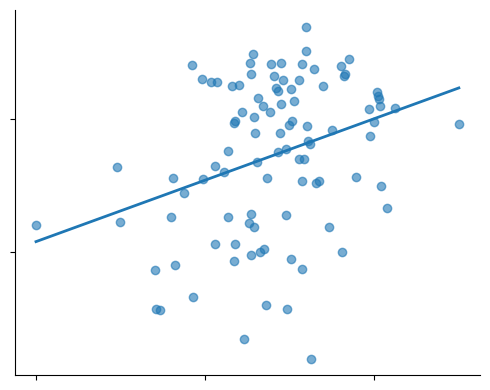

In [40]:
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import MaxNLocator

x = np.asarray(y_01[mask_dy]).reshape(-1, 1)
y = np.asarray(y_pred_cv)

reg = LinearRegression()
reg.fit(x, y)

x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
y_line = reg.predict(x_line)

r2 = reg.score(x, y)

fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(y_01[mask_dy], y_pred_cv, alpha=0.6)

ax.plot(
    x_line.ravel(),
    y_line,
    linewidth=2,
    #label=f"Linear fit, $R^2$ = {r2:.3f}"
)

# ax.set_xlabel("Real Values")
# ax.set_ylabel("Predicted Values")
# ax.set_title('Use RNN Predictions')
# 去掉上边框和右边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xticklabels([])
ax.set_yticklabels([])
# 每个坐标轴最多保留 3 个刻度
ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
#ax.set_title('Movie Likes Prediction from Emotional Dynamics')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [41]:
spearmanr(y_01[mask_dy], y_pred_cv)

SignificanceResult(statistic=0.2758257942352198, pvalue=0.0059769262775900955)

In [43]:
from scipy.stats import spearmanr
import numpy as np

# 5 metrics × 6 emotions
metrics = [
    "MC",
    "AC",
    "Instability",
    "Hurst",
    "Lambda"
]

emotions = [
    "Happiness",
    "Surprise",
    "Sadness",
    "Anger",
    "Disgust",
    "Fear"
]

# 


rho_matrix = np.zeros((5, 6))
p_matrix = np.zeros((5, 6))

for i, metric in enumerate(metrics):
    for j, emotion in enumerate(emotions):

        idx = i * 6 + j

        rho, p = spearmanr(
            X[:, idx],
            y,
            nan_policy="omit"
        )

        rho_matrix[i, j] = rho
        p_matrix[i, j] = p

        print(
            f"{metric:12s} | {emotion:10s} | "
            f"rho = {rho:.3f}, p = {p:.3e}"
        )

MC           | Happiness  | rho = -0.143, p = 1.596e-01
MC           | Surprise   | rho = -0.162, p = 1.100e-01
MC           | Sadness    | rho = -0.150, p = 1.392e-01
MC           | Anger      | rho = -0.005, p = 9.613e-01
MC           | Disgust    | rho = 0.001, p = 9.889e-01
MC           | Fear       | rho = -0.114, p = 2.651e-01
AC           | Happiness  | rho = 0.009, p = 9.318e-01
AC           | Surprise   | rho = 0.017, p = 8.673e-01
AC           | Sadness    | rho = 0.112, p = 2.707e-01
AC           | Anger      | rho = -0.119, p = 2.413e-01
AC           | Disgust    | rho = -0.091, p = 3.736e-01
AC           | Fear       | rho = -0.023, p = 8.198e-01
Instability  | Happiness  | rho = -0.095, p = 3.509e-01
Instability  | Surprise   | rho = -0.035, p = 7.346e-01
Instability  | Sadness    | rho = 0.142, p = 1.623e-01
Instability  | Anger      | rho = -0.191, p = 5.898e-02
Instability  | Disgust    | rho = -0.229, p = 2.348e-02
Instability  | Fear       | rho = -0.011, p = 9.122e-

## deep learning

In [48]:
X_valid = X_seq[mask].astype(np.float32)
y_valid = y_01.astype(np.float32)   # 你说这里就用 y_01，不再 mask

print("X_valid shape:", X_valid.shape)
print("y_valid shape:", y_valid.shape)


X_valid shape: (100, 2000, 6)
y_valid shape: (100,)


In [49]:


class MovieCurveDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# =========================
# 2. GRU 回归模型
# =========================

class GRURegressor(nn.Module):
    def __init__(
        self,
        input_dim=6,
        hidden_dim=64,
        num_layers=1,
        dropout=0.2,
        bidirectional=False
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        gru_out_dim = hidden_dim * (2 if bidirectional else 1)

        self.head = nn.Sequential(
            nn.Linear(gru_out_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, T, 6)
        out, h = self.gru(x)

        # 取最后一个时间点的隐藏状态
        last_out = out[:, -1, :]

        y_pred = self.head(last_out)
        return y_pred

In [50]:
class RNNRegressor(nn.Module):
    def __init__(
        self,
        input_dim=6,
        hidden_dim=64,
        num_layers=1,
        dropout=0.2,
        bidirectional=False
    ):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            nonlinearity="tanh",
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        out_dim = hidden_dim * (2 if bidirectional else 1)

        self.head = nn.Sequential(
            nn.Linear(out_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, h = self.rnn(x)
        last_out = out[:, -1, :]
        return self.head(last_out)
class LSTMRegressor(nn.Module):
    def __init__(
        self,
        input_dim=6,
        hidden_dim=64,
        num_layers=1,
        dropout=0.2,
        bidirectional=False
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        out_dim = hidden_dim * (2 if bidirectional else 1)

        self.head = nn.Sequential(
            nn.Linear(out_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, (h, c) = self.lstm(x)
        last_out = out[:, -1, :]
        return self.head(last_out)
class CNNRegressor(nn.Module):
    def __init__(
        self,
        input_dim=6,
        hidden_dim=64,
        dropout=0.2,
        bidirectional=False  # 保留参数接口，不实际使用
    ):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, T, 6)
        x = x.transpose(1, 2)  # -> (batch, 6, T)
        feat = self.conv(x)    # -> (batch, hidden_dim, T)
        feat = self.pool(feat).squeeze(-1)  # -> (batch, hidden_dim)
        return self.head(feat)
class TransformerRegressor(nn.Module):
    def __init__(
        self,
        input_dim=6,
        hidden_dim=64,
        num_layers=2,
        dropout=0.2,
        bidirectional=False,  # 保留参数接口，不实际使用
        nhead=4,
        max_len=2000
    ):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, hidden_dim)

        self.pos_embedding = nn.Parameter(
            torch.randn(1, max_len, hidden_dim) * 0.02
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, T, 6)
        B, T, D = x.shape

        x = self.input_proj(x)

        if T > self.pos_embedding.shape[1]:
            raise ValueError(
                f"T={T} exceeds max_len={self.pos_embedding.shape[1]}. "
                "Increase max_len in TransformerRegressor."
            )

        x = x + self.pos_embedding[:, :T, :]

        out = self.encoder(x)

        # 用平均池化，比只取最后一个时间点更稳
        feat = out.mean(dim=1)

        return self.head(feat)


In [51]:
def standardize_by_train(X_train, X_test):
    mean = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
    std = X_train.reshape(-1, X_train.shape[-1]).std(axis=0)
    std[std == 0] = 1.0

    X_train_z = (X_train - mean) / std
    X_test_z = (X_test - mean) / std

    return X_train_z.astype(np.float32), X_test_z.astype(np.float32)


def train_one_fold(
    X_train,
    y_train,
    X_test,
    y_test,
    hidden_dim=64,
    num_layers=1,
    dropout=0.2,
    bidirectional=False,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=8,
    max_epochs=300,
    patience=30,
    device=None
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    train_dataset = MovieCurveDataset(X_train, y_train)
    test_dataset = MovieCurveDataset(X_test, y_test)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = GRURegressor(
        input_dim=X_train.shape[-1],
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=bidirectional
    ).to(device)

    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_loss = np.inf
    best_state = None
    wait = 0

    for epoch in range(max_epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_losses.append(loss.item())

        # 用 test fold 做 early stopping
        # 样本少时这样可以先快速探索；正式论文建议再划分 validation
        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                pred = model(xb)
                loss = criterion(pred, yb)
                val_losses.append(loss.item())

        val_loss = np.mean(val_losses)

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()

    preds = []

    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            pred = model(xb)
            preds.append(pred.cpu().numpy())

    y_pred = np.vstack(preds).ravel()

    return y_pred, model

In [52]:
# =========================
# 3. KFold 训练和评估
# =========================

def evaluate_gru_kfold(
    X_valid,
    y_valid,
    n_splits=4,
    random_state=42,
    hidden_dim=64,
    num_layers=1,
    dropout=0.2,
    bidirectional=False,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=8,
    max_epochs=300,
    patience=30
):
    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_results = []
    y_oof = np.zeros_like(y_valid, dtype=np.float32)

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_valid), start=1):
        print(f"\nFold {fold}/{n_splits}")

        X_train = X_valid[train_idx]
        X_test = X_valid[test_idx]
        y_train = y_valid[train_idx]
        y_test = y_valid[test_idx]

        X_train_z, X_test_z = standardize_by_train(X_train, X_test)

        y_pred, _ = train_one_fold(
            X_train_z,
            y_train,
            X_test_z,
            y_test,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=bidirectional,
            lr=lr,
            weight_decay=weight_decay,
            batch_size=batch_size,
            max_epochs=max_epochs,
            patience=patience
        )

        y_oof[test_idx] = y_pred

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred)

        sp, sp_p = spearmanr(y_test, y_pred)
        if np.isnan(sp):
            sp = 0.0

        fold_results.append({
            "fold": fold,
            "r2": r2,
            "mae": mae,
            "rmse": rmse,
            "spearman": sp,
            "spearman_p": sp_p
        })

        print(
            f"R2={r2:.3f}, MAE={mae:.3f}, "
            f"RMSE={rmse:.3f}, Spearman={sp:.3f}"
        )

    result_df = pd.DataFrame(fold_results)

    oof_r2 = r2_score(y_valid, y_oof)
    oof_mae = mean_absolute_error(y_valid, y_oof)
    oof_rmse = mean_squared_error(y_valid, y_oof)
    oof_sp, oof_sp_p = spearmanr(y_valid, y_oof)

    if np.isnan(oof_sp):
        oof_sp = 0.0

    summary = {
        "model": "GRU",
        "fold_R2_mean": result_df["r2"].mean(),
        "fold_R2_std": result_df["r2"].std(),
        "fold_MAE_mean": result_df["mae"].mean(),
        "fold_RMSE_mean": result_df["rmse"].mean(),
        "fold_spearman_mean": result_df["spearman"].mean(),
        "fold_spearman_std": result_df["spearman"].std(),
        "oof_R2": oof_r2,
        "oof_MAE": oof_mae,
        "oof_RMSE": oof_rmse,
        "oof_spearman": oof_sp,
        "oof_spearman_p": oof_sp_p
    }

    return result_df, summary, y_oof

In [54]:
def evaluate_deep_model_kfold(
    model_name,
    model_class,
    X_valid,
    y_valid,
    model_kwargs=None,
    n_splits=4,
    random_state=42,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=8,
    max_epochs=300,
    patience=30
):
    X_valid = X_valid.astype(np.float32)
    y_valid = y_valid.astype(np.float32)

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_results = []
    y_oof = np.zeros_like(y_valid, dtype=np.float32)

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_valid), start=1):
        print(f"{model_name} | Fold {fold}/{n_splits}")

        X_train = X_valid[train_idx]
        X_test = X_valid[test_idx]
        y_train = y_valid[train_idx]
        y_test = y_valid[test_idx]

        X_train_z, X_test_z = standardize_by_train(X_train, X_test)

        y_pred, _ = train_one_fold(
            model_class=model_class,
            X_train=X_train_z,
            y_train=y_train,
            X_test=X_test_z,
            y_test=y_test,
            model_kwargs=model_kwargs,
            lr=lr,
            weight_decay=weight_decay,
            batch_size=batch_size,
            max_epochs=max_epochs,
            patience=patience
        )

        y_oof[test_idx] = y_pred

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        sp, sp_p = spearmanr(y_test, y_pred)
        if np.isnan(sp):
            sp = 0.0

        fold_results.append({
            "model": model_name,
            "fold": fold,
            "r2": r2,
            "mae": mae,
            "rmse": rmse,
            "spearman": sp,
            "spearman_p": sp_p
        })

    fold_df = pd.DataFrame(fold_results)

    oof_r2 = r2_score(y_valid, y_oof)
    oof_mae = mean_absolute_error(y_valid, y_oof)
    oof_rmse = np.sqrt(mean_squared_error(y_valid, y_oof))

    oof_sp, oof_sp_p = spearmanr(y_valid, y_oof)
    if np.isnan(oof_sp):
        oof_sp = 0.0

    summary = {
        "model": model_name,
        "fold_R2_mean": fold_df["r2"].mean(),
        "fold_R2_std": fold_df["r2"].std(),
        "fold_MAE_mean": fold_df["mae"].mean(),
        "fold_RMSE_mean": fold_df["rmse"].mean(),
        "fold_spearman_mean": fold_df["spearman"].mean(),
        "fold_spearman_std": fold_df["spearman"].std(),
        "oof_R2": oof_r2,
        "oof_MAE": oof_mae,
        "oof_RMSE": oof_rmse,
        "oof_spearman": oof_sp,
        "oof_spearman_p": oof_sp_p
    }

    return fold_df, summary, y_oof

In [55]:
def train_one_fold(
    model_class,
    X_train,
    y_train,
    X_test,
    y_test,
    model_kwargs=None,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=8,
    max_epochs=300,
    patience=30,
    device=None
):
    if model_kwargs is None:
        model_kwargs = {}

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    train_dataset = MovieCurveDataset(X_train, y_train)
    test_dataset = MovieCurveDataset(X_test, y_test)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = model_class(
        input_dim=X_train.shape[-1],
        **model_kwargs
    ).to(device)

    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_loss = np.inf
    best_state = None
    wait = 0

    for epoch in range(max_epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                pred = model(xb)
                loss = criterion(pred, yb)
                val_losses.append(loss.item())

        val_loss = np.mean(val_losses)

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()

    preds = []

    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            pred = model(xb)
            preds.append(pred.cpu().numpy())

    y_pred = np.vstack(preds).ravel()

    return y_pred, model

In [56]:
torch.manual_seed(42)
np.random.seed(42)

model_configs = {
    "RNN": {
        "class": RNNRegressor,
        "kwargs": {
            "hidden_dim": 64,
            "num_layers": 1,
            "dropout": 0.3,
            "bidirectional": False
        }
    },

}


all_fold_results = []
all_summaries = []
all_oof_preds = {}

for model_name, cfg in model_configs.items():
    print("\n==============================")
    print("Running:", model_name)
    print("==============================")

    fold_df, summary, y_oof = evaluate_deep_model_kfold(
        model_name=model_name,
        model_class=cfg["class"],
        X_valid=X_valid,
        y_valid=y_valid,
        model_kwargs=cfg["kwargs"],
        n_splits=5,
        random_state=42,
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=8,
        max_epochs=300,
        patience=30
    )

    all_fold_results.append(fold_df)
    all_summaries.append(summary)
    all_oof_preds[model_name] = y_oof


fold_results_df = pd.concat(all_fold_results, axis=0, ignore_index=True)
summary_df = pd.DataFrame(all_summaries)

summary_df = summary_df.sort_values("oof_spearman", ascending=False)

print("\nSummary:")
print(summary_df)


Running: RNN
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5

Summary:
  model  fold_R2_mean  fold_R2_std  fold_MAE_mean  fold_RMSE_mean  \
0   RNN      0.149294     0.207718       0.110906        0.140895   

   fold_spearman_mean  fold_spearman_std    oof_R2   oof_MAE  oof_RMSE  \
0            0.398496           0.105199  0.206706  0.110906   0.14142   

   oof_spearman  oof_spearman_p  
0      0.422622        0.000012  


In [57]:
r_list[0] = summary_df.loc[summary_df["model"] == "RNN", "oof_spearman"].values[0]
r2_list[0] = summary_df.loc[summary_df["model"] == "RNN", "oof_R2"].values[0]
p_list[0] = summary_df.loc[summary_df["model"] == "RNN", "oof_spearman_p"].values[0]

In [58]:
import numpy as np
import torch
import random


# ============================================================
# 1. Observed RNN performance
# ============================================================

rho_obs = summary_df.loc[
    summary_df["model"] == "RNN",
    "oof_spearman"
].values[0]

r2_obs = summary_df.loc[
    summary_df["model"] == "RNN",
    "oof_R2"
].values[0]

print("Observed RNN Spearman rho:", rho_obs)
print("Observed RNN R2:", r2_obs)


# ============================================================
# 2. Permutation test
# ============================================================

N_PERM = 1000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

perm_rhos = np.zeros(N_PERM)


for p in range(N_PERM):

    # --------------------------------------------------------
    # Shuffle y labels
    # --------------------------------------------------------

    y_perm = rng.permutation(y_valid)

    # --------------------------------------------------------
    # Fix random seed
    # 保证每次 permutation 的模型初始化/训练随机性一致
    # --------------------------------------------------------

    seed = RANDOM_STATE

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # --------------------------------------------------------
    # Complete 5-fold CV using permuted labels
    # --------------------------------------------------------

    perm_fold_df, perm_summary, perm_y_oof = evaluate_deep_model_kfold(
        model_name="RNN",
        model_class=RNNRegressor,
        X_valid=X_valid,
        y_valid=y_perm,
        model_kwargs={
            "hidden_dim": 64,
            "num_layers": 1,
            "dropout": 0.3,
            "bidirectional": False
        },
        n_splits=5,
        random_state=42,
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=8,
        max_epochs=300,
        patience=30
    )

    # --------------------------------------------------------
    # Save permutation OOF Spearman rho
    # --------------------------------------------------------

    perm_rhos[p] = perm_summary["oof_spearman"]

    # if (p + 1) % 10 == 0:
    #     print(
    #         f"Permutation {p + 1:4d}/{N_PERM} | "
    #         f"rho = {perm_rhos[p]:.4f}"
    #     )


# ============================================================
# 3. One-sided permutation p-value
#
# H0: prediction is no better than random labels
# H1: observed rho > permutation rho
# ============================================================

perm_p = (
    np.sum(perm_rhos >= rho_obs) + 1
) / (
    N_PERM + 1
)


# ============================================================
# 4. Results
# ============================================================

print("\n======================================")
print("Observed rho          :", rho_obs)
print("Observed R2           :", r2_obs)
print("Permutation mean rho  :", perm_rhos.mean())
print("Permutation std rho   :", perm_rhos.std())
print("Permutation max rho   :", perm_rhos.max())
print("Permutation p-value   :", perm_p)
print("======================================")

Observed RNN Spearman rho: 0.42262226222622257
Observed RNN R2: 0.20670616626739502
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5


RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold

In [59]:
r_list[0] = rho_obs
r2_list[0] = r2_obs

# 注意：这里改成 permutation p-value
p_list[0] = perm_p

# 保存完整的 1000 个 permutation rho
perm_rho_list[0] = perm_rhos.copy()

/tmp/ipykernel_248282/2752953929.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


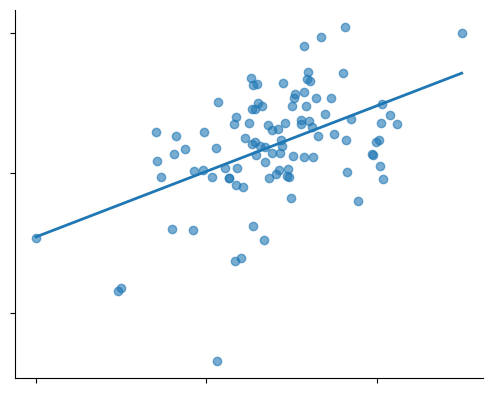

In [60]:
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import MaxNLocator

x = np.asarray(y_valid).reshape(-1, 1)
y = np.asarray(all_oof_preds["RNN"])

reg = LinearRegression()
reg.fit(x, y)

x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
y_line = reg.predict(x_line)

r2 = reg.score(x, y)

fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(y_valid, all_oof_preds["RNN"], alpha=0.6)

ax.plot(
    x_line.ravel(),
    y_line,
    linewidth=2,
    #label=f"Linear fit, $R^2$ = {r2:.3f}"
)

# ax.set_xlabel("Real Values")
# ax.set_ylabel("Predicted Values")
# ax.set_title('Use RNN Predictions')
# 去掉上边框和右边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xticklabels([])
ax.set_yticklabels([])
# 每个坐标轴最多保留 3 个刻度
ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
#ax.set_title('Movie Likes Prediction from Emotional Dynamics')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [61]:
spearmanr(y_valid, all_oof_preds["RNN"]),f"Linear fit, $R^2$ = {r2:.3f}"

(SignificanceResult(statistic=0.42262226222622257, pvalue=1.1860184937701488e-05),
 'Linear fit, $R^2$ = 0.229')

## plt

In [68]:
r_list

array([ 0.42262226,  0.27582579, -0.0960988 , -0.1497555 ,  0.15236948,
        0.1529553 ])

In [69]:
import numpy as np

def permutation_pvalue(r_obs, perm_rhos):
    perm_rhos = np.asarray(perm_rhos, dtype=float)

    p = (
        np.sum(np.abs(perm_rhos) >= np.abs(r_obs)) + 1
    ) / (len(perm_rhos) + 1)

    return p


perm_p_list = [
    permutation_pvalue(r_obs, perm_rhos)
    for r_obs, perm_rhos in zip(r_list, perm_rho_list)
]

print(perm_p_list)

[0.02197802197802198, 0.03996003996003996, 0.4565434565434565, 0.26673326673326675, 0.24075924075924077, 0.26373626373626374]


# likes

In [71]:
p_list

array([0.02197802, 0.01298701, 0.6963037 , 0.83716284, 0.09190809,
       0.12869266])

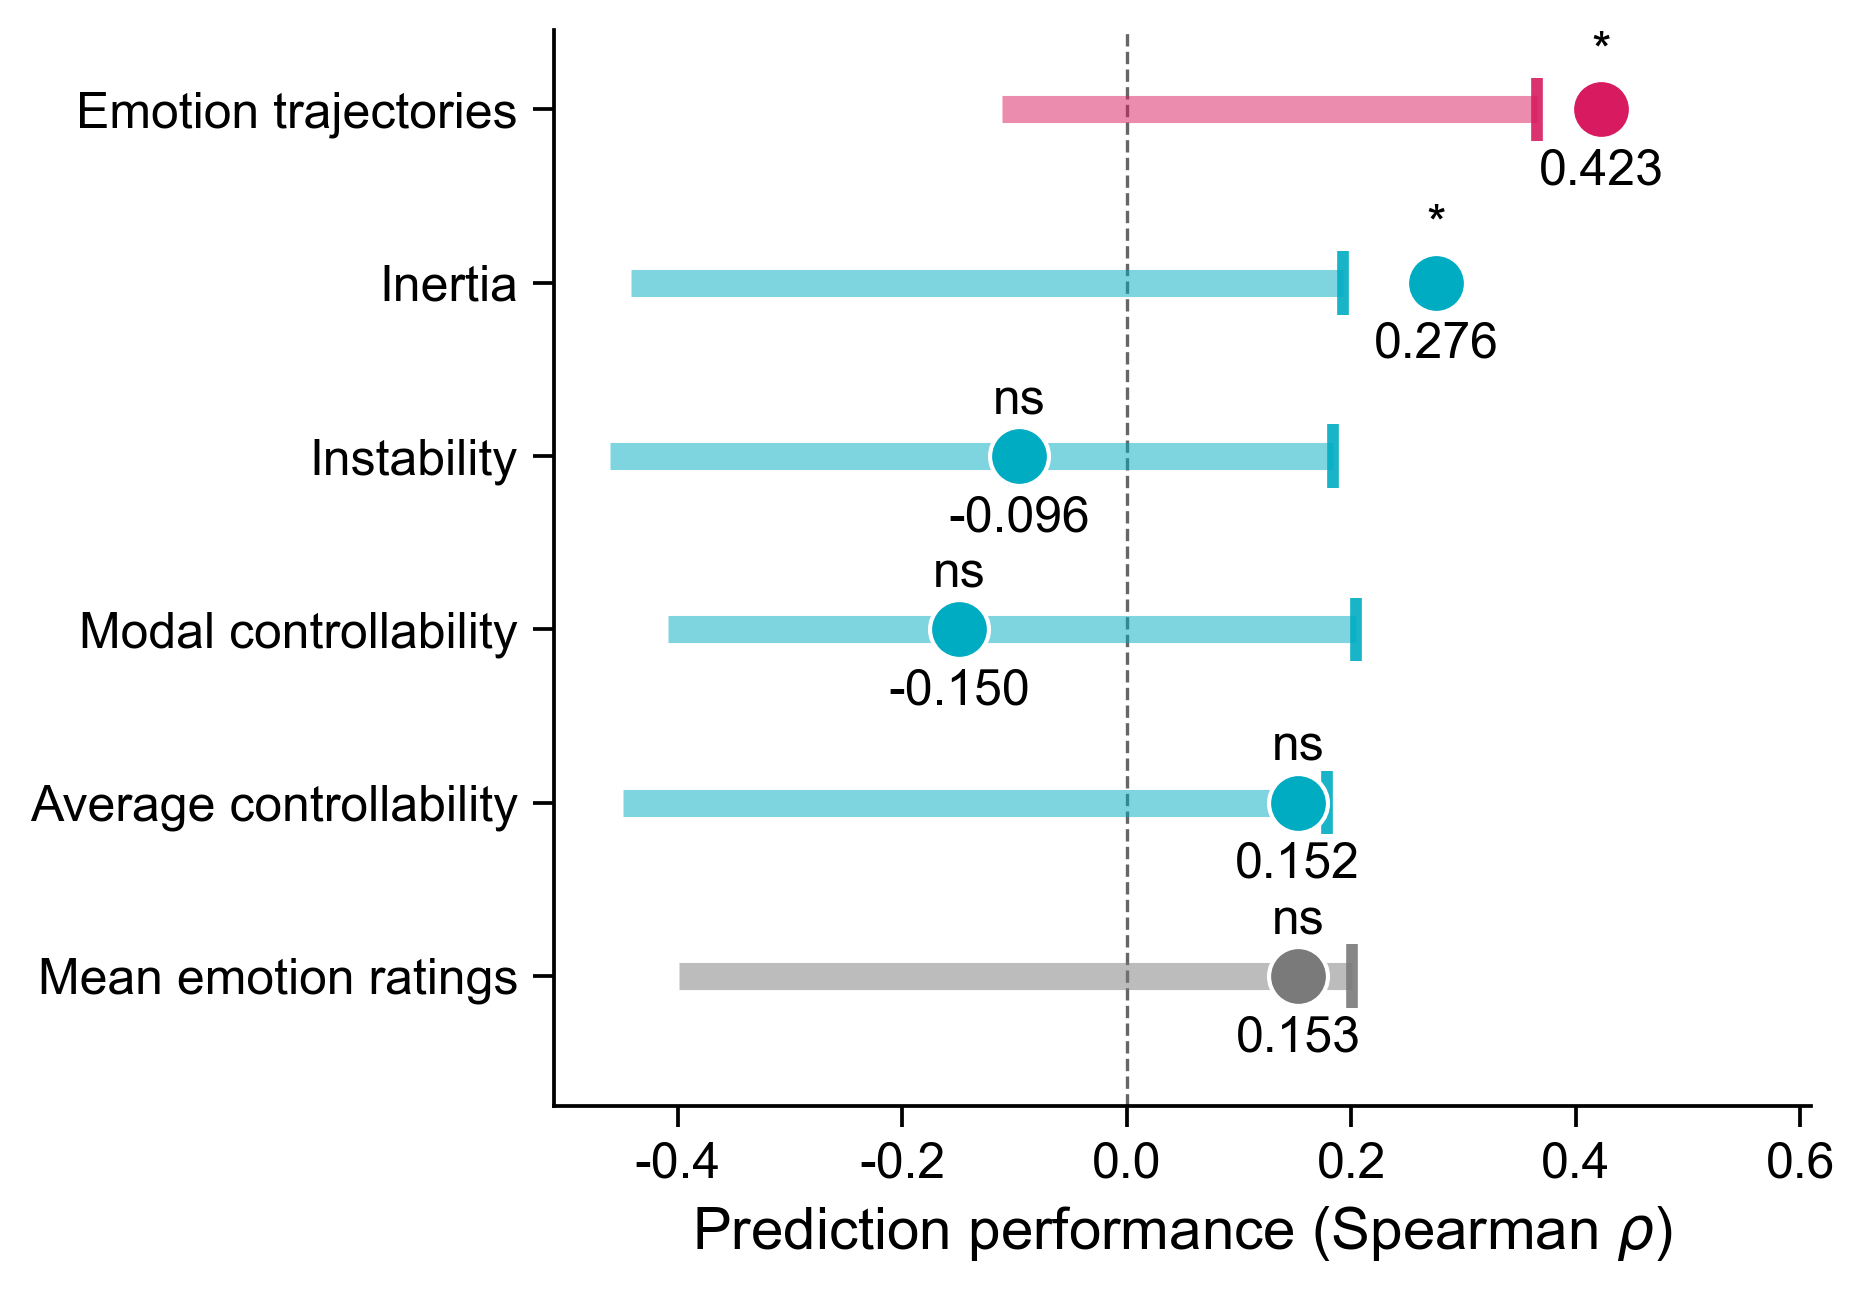

In [72]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 13

# ============================================================
# 1. Methods
# ============================================================

methods = [
    "Emotion trajectories",
    "Inertia",
    "Instability",
    "Modal controllability",
    "Average controllability",
    "Mean emotion ratings"
]

# ============================================================
# 2. Colors
# 更饱和一点
# ============================================================

color_trajectory = "#D81B60"   # stronger magenta
color_dynamic    = "#00ACC1"   # stronger cyan-blue
color_static     = "#7A7A7A"   # darker gray

feature_colors = [
    color_trajectory,
    color_dynamic,
    color_dynamic,
    color_dynamic,
    color_dynamic,
    color_static
]

# ============================================================
# 3. Significance
# ============================================================

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# ============================================================
# 4. Plot
# ============================================================

def plot_prediction(
    r_list,
    p_list,
    perm_rho_list,
    save_name,
    xlim=None,
    one_sided=True
):
    values = np.asarray(r_list, dtype=float)
    p_values = np.asarray(p_list, dtype=float)

    # -----------------------------
    # 行间距拉开一点
    # -----------------------------
    y_gap = 1.20
    y_pos = np.arange(len(methods)) * y_gap

    fig, ax = plt.subplots(
        figsize=(6.4, 4.5),
        dpi=300
    )

    # ========================================================
    # rho = 0 reference
    # ========================================================

    ax.axvline(
        0,
        linestyle="--",
        color="black",
        linewidth=0.8,
        alpha=0.60,
        zorder=0
    )

    # ========================================================
    # Plot each feature
    # ========================================================

    for i in range(len(methods)):

        value = values[i]
        p = p_values[i]
        color = feature_colors[i]

        perms = np.asarray(perm_rho_list[i], dtype=float)
        perms = perms[np.isfinite(perms)]

        # ----------------------------------------------------
        # 单侧/双侧 permutation 区间
        # ----------------------------------------------------
        if one_sided:
            perm_low = np.percentile(perms, 0)
            perm_high = np.percentile(perms, 95)
        else:
            perm_low = np.percentile(perms, 2.5)
            perm_high = np.percentile(perms, 97.5)

        # ====================================================
        # Horizontal interval line
        # ====================================================

        ax.plot(
            [perm_low, perm_high],
            [y_pos[i], y_pos[i]],
            color=color,
            linewidth=6.5,
            alpha=0.50,
            solid_capstyle="butt",
            zorder=1
        )

        # ====================================================
        # Right cutoff line
        # ====================================================

        ax.plot(
            [perm_high, perm_high],
            [y_pos[i] - 0.22, y_pos[i] + 0.22],
            color=color,
            linewidth=2.8,
            alpha=0.90,
            solid_capstyle="butt",
            zorder=2
        )

        # ====================================================
        # Observed rho point
        # ====================================================

        ax.scatter(
            value,
            y_pos[i],
            s=200,                 # 更大一点
            color=color,
            edgecolors="white",
            linewidth=1.0,
            zorder=4
        )

        # ====================================================
        # Numeric value
        # 放到点下面
        # ====================================================

        ax.text(
            value,
            y_pos[i] + 0.43,
            f"{value:.3f}",
            va="center",
            ha="center",
            fontsize=12,
            color="black"
        )

        # ====================================================
        # Significance
        # 放到点上面
        # ====================================================

        star = p_to_star(p)

        ax.text(
            value,
            y_pos[i] - 0.38,
            star,
            ha="center",
            va="center",
            fontsize=12,
            color="black"
        )

    # ========================================================
    # Axis
    # ========================================================

    ax.set_yticks(y_pos)
    ax.set_yticklabels(methods, fontsize=13)

    ax.invert_yaxis()

    ax.set_ylim([
        y_pos[-1] + 0.9,
        -0.55
    ])

    # 如果没传 xlim，就自动按数据范围给一点边距
    if xlim is None:
        all_vals = list(values)
        for perms in perm_rho_list:
            perms = np.asarray(perms, dtype=float)
            perms = perms[np.isfinite(perms)]
            if len(perms) > 0:
                all_vals.extend([np.min(perms), np.max(perms)])
        xmin = min(all_vals)
        xmax = max(all_vals)
        pad = 0.05
        ax.set_xlim(xmin - pad, xmax + pad)
    else:
        ax.set_xlim(xlim)

    ax.set_xlabel(
        r"Prediction performance (Spearman $\rho$)",
        fontsize=14
    )

    ax.set_ylabel("")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.9)
    ax.spines["bottom"].set_linewidth(0.9)

    ax.tick_params(
        axis="both",
        labelsize=12,
        width=0.9,
        length=5
    )

    plt.tight_layout()

    plt.savefig(
        f"{save_name}.svg",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        f"{save_name}.pdf",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# 5. Plot
# ============================================================

plot_prediction(
    r_list=r_list,
    p_list=perm_p_list,
    perm_rho_list=perm_rho_list,
    save_name="movie_likes_prediction",
    xlim=None,
    one_sided=True
)